# 5 Continuous basis sets

In [1]:
# import all python add-ons etc that will be needed later on
%matplotlib inline
# %matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
plt.rcParams.update({'font.size': 14})  # set font size for plots

## 5.1 Example
Suppose a wavefunction $R$ represents the radial part of the ground state of a hydrogen atom then a continuous basis set is needed because the wavefunction depends on spatial coordinates, and in particular on the radial distance from the nucleus, $r$. At this point, $R$ is just the idea of the wavefunction as no basis or representation has yet been determined. The wavefunction can now be defined by left multiplying with a bra; the result is the value of the function at $r$,

$$\displaystyle r|R\rangle = R(r)$$

If $R$ were a cosine, the expression would be $\langle r | \cos\rangle = \cos(r)$ where $\cos$ is the operator that converts, or maps $r$ into $\cos(r)$. This is not the way we usually think of functions and it seems to be ‘back to front’. It may be useful therefore to think of $\langle r| R\rangle = R(r)$ as extracting the coefficient of $R$ at the point $r$, which is the value of the function itself, $R(r)$. The equivalent process with a discrete basis set is equation (32), which extracts the coefficient $a$ from $\varphi$.

If a basis set is defined as the set of an orthogonal polynomial $P_n$ then this basis is $\begin{bmatrix}P_0 & P_1& P_2 &\cdots & P_\infty )\end{bmatrix}$  and the bra is

$$\displaystyle \langle r| = \begin{bmatrix}P_0(r)& P_1(r)& P_2(r) &\cdots & P_\infty (r)\end{bmatrix}$$

where the $P_0(r)$ etc. are functions of $r$. For example, if $P$ are the Legendre polynomials, then


$$\displaystyle \langle r|=\begin{bmatrix}1 &\displaystyle \frac{3x^2 -1}{2} &\displaystyle\frac{5x^3 -3x}{2} & \cdots \end{bmatrix}$$

and the terms are the polynomials. The corresponding ket is
  
$$\displaystyle |P_n〉=\begin{bmatrix}0 &0 &\cdots & 1 &\cdots\end{bmatrix}$$

where the $1$ is in the $n^{th}$ position for polynomial $P_n$. For example, the product 

$$\displaystyle \langle r|P_2\rangle = P_2(r) = \frac{3x^2 - 1}{2} $$

and is the value of the function at $r$, and this is consistent with the notion that $P_2$ operates on $r$ to produce the function $P_2(r)$.

It would have been just as easy to choose a basis in momentum $p$ which is $[p]$ rather than $r$, then the wavefunction would be $\langle p|R\rangle = R(p)$, which is now a function of $p$ the momentum. 

To represent the whole wavefunction $\psi$ with its radial and angular parts then it is necessary to define a different basis set to encompass all these three coordinates, $(r, \theta, \varphi)$ which can be represented as $(r, \theta, \varphi)$ where there are three indices to each basis vector but $|(r, \theta, \varphi)\rangle $ is still an infinite length column vector and therefore, $\langle (r, \theta, \varphi)|\psi\rangle = \psi(r, \theta, \varphi)$ extracts the value at $r, \theta, \varphi$.

At this point, however, it becomes unnecessary and rather complicated to continue with the bra-ket form and it is simpler to revert to normal functions but still holding onto the idea of basis sets. The basis set could comprise almost any set of functions provided that they can be made orthogonal over the range of values needed, alternatively the known orthogonal polynomials, Legendre, Hermite, Chebychev, etc. could be used. A function $f(x)$ can be expanded as a linear combination of orthogonal functions and if these from a set of wavefunctions $\psi$ then

$$\displaystyle f(x)= c_0\psi_0(x)  +c_1\psi_1(x) +\cdots +\qquad\tag{33}$$

with coefficients $c_n$. The wavefunction need not be specified yet, but whatever it is it must be orthogonal given different quantum numbers. This is exactly what is done in the general Fourier series described in Chapter 9. There it is shown that the coefficients are 

$$\displaystyle c_n=\int\psi_n(x)f(x)dx \qquad\tag{34}$$

If the function $f$ is represented as the ket $| f\rangle$, suppose that left multiplying by the bra $\langle n |$ will extract the coefficient $c_n$ in the same manner as for a discrete basis set. However, in a continuous basis the bra-ket represents an integral, thus $\langle n | f\rangle \equiv \int \psi_n(x)f(x)dx$ . Equation (34) provides a method of calculating the coefficients of the expansion provided $f$ has the same range as the wavefunction. To illustrate this, particle in a box wavefunctions are used to form the target function 

$$\displaystyle f(x) = 64 - (2 - x)^6$$

where the length of the box $L = 4$, or $0 \le x \le 4$. The calculation is in the algorithm below. The series $w(x)$ approximates $f(x)$ in the basis set of the $\psi$ as

$$w(x)= \psi_0(x)\int \psi_0(x)f(x)dx +\psi_1(x)\int \psi_1(x)f(x)dx+\cdots +$$

The first eight terms ($n=0\to 7$) are shown in figure 5 where thee reproduction of the function $64 - (2 - x)^6$ is approximated by weighted particle in a box functions 

$$\displaystyle \psi_n(x)=\sqrt{\frac{2}{L}}\sin\left(n\pi\frac{x}{L} \right)$$

The code below takes no account of the fact that the integral with $n=0,2,4\cdots$ is zero because of the property of the sine so that very few terms produce a quite good approximation.

![Drawing](matricesQM-fig5.png)

Figure 5. Comparison of a series made up of weighted sine functions equation (8.33) and the target function $64 - (2 - x)^6$. A far better fit is obtained if more  terms are added.
________
Why this method works can be appreciated by realizing that at larger values of $n$ the sine function oscillates more rapidly and so allows for the rapid rising and falling part of the curves. The coefficients automatically adjust the proportion of each sine wave to describe the target equation. Other target functions can be tried quite easily by, changing $f$, however, the less the function looks like a sine wave, such as $\exp(-x)$, the greater will be the number of terms that are needed to produce a good description of the function, $\gt 100$ in that case.

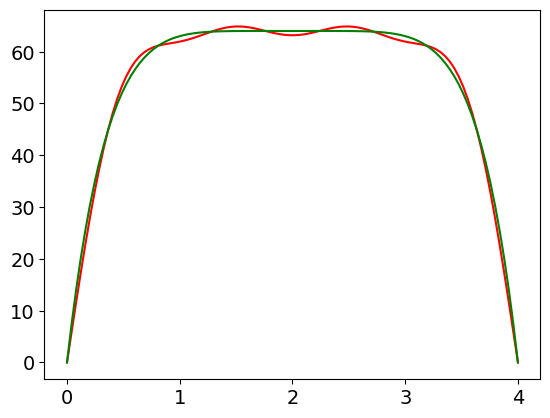

In [3]:
# Algorithm to calculate eqn 33
num = 8                                           # number of terms in series  fig 8.5
L = 4
m = 100
wf = np.zeros(m,dtype = float)                    # array to hold calculated wavefunction
x  = np.linspace(0,L,m)                            # make m  x values  0 to L

psi = lambda x,n: np.sqrt(2/L)*np.sin(n*np.pi*x/L)
f   = lambda x:64 -(2 - x)**6;                       # target function

q = lambda x,n: psi(x,n)*f(x)                     #  function to integrate using quad()

for n in range(num):                              # sum over numer of terms
    coef = quad( q ,0, L, args = (n))[0]          # calculate coefficients c eqn (8.34)
    wf[:]= wf[:] + psi(x[:],n)*coef               # add up over all x
    
#plt.plot(x,wf   ,color='red')                    # plot fig 5
#plt.plot(x,f(x) ,color='green')
#plt.show()